In [ ]:
!pip install --upgrade tensorflow
!pip install opencv-python-headless
!pip install keras


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
# Google Drive
from google.colab import drive
drive.mount('/content/drive')  # Google Drive'ı bağla
import numpy as np
import random
import math
import csv
import cv2
import os


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
inputBasePath = "/content/drive/MyDrive/horses_and_zebras/images" #resimlerin olduğu klasör
outputBasePath = "/content/drive/MyDrive/horses_and_zebras/imageArrays"

In [ ]:
!ls -l "/content/drive/My Drive/my_dataset/horse/"
!ls -l "/content/drive/My Drive/my_dataset/zebra/"

ls: cannot access '/content/drive/My Drive/my_dataset/horse/': No such file or directory
ls: cannot access '/content/drive/My Drive/my_dataset/zebra/': No such file or directory


In [ ]:
image_width = 224 # farklı boyutlardaki resimleri idealize ediyoruz
image_height = 224

In [ ]:
classes = ['Horse','Zebra']


In [ ]:
os.chdir(inputBasePath) #chdir -> change directory, inputBasePath yoluyla verilen dizine git

X = [] # resimleri yani girdileri yani X değerlerini tutmak için dizi
Y = [] # etiketleri yani Y değerlerini tutmak için dizi. her bir resmin etiketi içinde yer aldığı klasörün adı zaten

i = 0
for class1 in classes:
  os.chdir(class1) #base yoldan sonra sıradaki sınıfı gösteren klasöre konumlan
  print('=> '+class1) #o an üzerinde bulunulan sınıfı (klasör adını) yaz
  for files in os.listdir('./'): # nokta mevcut dizini gösteriyor. ./ mevcut dizin altındakiler
    img = cv2.imread(files) #dosya yolundan resmi binary array olarak okuma.resmi grayscale almak için ikinci parametreye 0 yazılır cv2.imread(files,0)
    img = cv2.resize(img, (image_width,image_height)) #isteğe bağlı olarak resize edilebilir
    X.append(img) #resmi oluşturan bit dizisini X'e ekle
    Y.append(class1) # bu resmin sınıfı içinde bulunduğu klasör adı. resmin etiketi olarak bunu Y'ye ekle
    i = i + 1
  os.chdir('..') #bir üst dizine çık. bu sınıfla ve bunu içeren klasörler işimiz bitti

print("X : ",len(X))
print("Y : ",len(Y))

X = np.array(X).reshape(-1,image_width,image_height,3) #-1 ile verilen ilk değerin yerinde toplam resim adedi var;
                #bu aynı kalacak. diğer parametreler verilen width ve height'e göre ve resmin renkli olduğunu
                #belirten 3 ile yeniden şekillendirilecek
Y = np.array(Y) #etiket adlarını içeren Y'yi reshape etmeye gerek yok.

print("X : ",X.shape)
print("Y : ",Y.shape)

print("X : ",len(X))
print("Y : ",len(Y))

os.chdir('..') #bir üst dizine daha çıkıp sonra imagearrays klasörüne gidersek zaten outputBasePath'e ulaşmış olacağız
os.chdir("imageArrays")
# üstteki iki satır yerine bunu direkt chdir(outputBasePath) olarak da yapabilirdik
np.save(str(image_width)+'x'+str(image_height)+'_images', X) #diziyi kaydederken dosya adını en x boy_images olarak adlandır.
                                                            #'224x224_images' gibi
np.save(str(image_width)+'x'+str(image_height)+'_labels', Y) #diziyi kaydederken dosya adını en x boy_labels olarak adlandır.

print("[ INFO - STAGE1 ]  NUMPY ARRAY CREATION COMPLETED \n ")

=> Horse
=> Zebra
X :  80
Y :  80
X :  (80, 224, 224, 3)
Y :  (80,)
X :  80
Y :  80
[ INFO - STAGE1 ]  NUMPY ARRAY CREATION COMPLETED 
 


In [ ]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import MaxPool2D # üstteki MaxPooling2D ile aynı şey. ister onu ister bunu kullan.
#kodda ikisi de kullanıldığı için eklendi. yoksa biri ile yapılsaydı da olurdu.
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD

In [ ]:
data = np.load(r"/content/drive/MyDrive/horses_and_zebras/imageArrays/224x224_images.npy")
labels = np.load(r"/content/drive/MyDrive/horses_and_zebras/imageArrays/224x224_labels.npy")
data.shape

(80, 224, 224, 3)

In [ ]:
labels

array(['Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse',
       'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse',
       'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse',
       'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse',
       'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Horse',
       'Horse', 'Horse', 'Horse', 'Horse', 'Horse', 'Zebra', 'Zebra',
       'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra',
       'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra',
       'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra',
       'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra',
       'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra', 'Zebra',
       'Zebra', 'Zebra', 'Zebra'], dtype='<U5')

In [ ]:
labelEn = LabelEncoder() #string olan etiketleri 0 1 2 şeklinde kodla
labels = labelEn.fit_transform(labels)
labels = to_categorical(labels)

In [ ]:
labels

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.

In [ ]:
#veri array'e kaydedilmeden önce reshape edildiğinden array den okununca da düzgün gelir. yeniden reshape etmeye gerek yok
#eğer array'e atarken son değer 3 olarak yazılmasaydı burada reshape gerekirdi

#data =  data.reshape(-1,image_width , image_height , 3)

# train -test split
#%20 test %80 eğitim seti olacak şekilde böl
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size = .20, shuffle = True)


print(
"""
x_train shape: {}
x_test shape: {}
y_train shape: {}
y_test shape: {}

""".format(x_train.shape, x_test.shape, y_train.shape, y_test.shape))


x_train shape: (64, 224, 224, 3)
x_test shape: (16, 224, 224, 3)
y_train shape: (64, 2)
y_test shape: (16, 2)




In [ ]:
x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean)/x_train_std
x_test = (x_test - x_test_mean)/x_test_std

In [ ]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = .10, shuffle = True,random_state=42)


In [ ]:
def model1(input_shape=(image_width ,image_height ,3), num_classes = 2): #parametrelerin varsayılan değerleri var.
    #modelin giriş shape'i ve class sayısı= 3
    #burada oluşturulan model VGG16 mimarisi aslında. değiştirilebilir.
	model = Sequential()
	chanDim = -1

	model.add(Conv2D(64, (3,3), padding="same",input_shape=input_shape))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(64, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(MaxPooling2D(pool_size=(2, 2)))

	# 2.Layer (CONV => RELU => CONV => RELU) * 2 => POOL
	model.add(Conv2D(128, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(128, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(MaxPooling2D(pool_size=(2, 2)))

	# 3.Layer (CONV => RELU => CONV => RELU) * 2 => POOL
	model.add(Conv2D(256, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(256, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(256, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(MaxPooling2D(pool_size=(2, 2)))

# 4.Layer (CONV => RELU => CONV => RELU) * 2 => POOL
	model.add(Conv2D(512, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(512, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(512, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(MaxPooling2D(pool_size=(2, 2)))

	# 5.Layer (CONV => RELU => CONV => RELU) * 2 => POOL
	model.add(Conv2D(512, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(512, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(Conv2D(512, (3,3), padding="same"))
	model.add(Activation("relu"))
	model.add(BatchNormalization(axis=chanDim))
	model.add(MaxPooling2D(pool_size=(2, 2)))

 # 1. TAM BAĞLANTI KATMANI
	model.add(Flatten())
	model.add(Dense(4096))
	model.add(Activation("relu"))
	model.add(BatchNormalization())
	model.add(Dropout(0.5))

	# 2. TAM BAĞLANTI KATMANI
	model.add(Flatten())
	model.add(Dense(4096))
	model.add(Activation("relu"))
	model.add(BatchNormalization())
	model.add(Dropout(0.5))

	# SOFTMAX
	model.add(Dense(num_classes))
	model.add(Activation("softmax"))

	return model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, BatchNormalization, GlobalAveragePooling2D

# Modeli oluşturan fonksiyon
def model2(input_shape=(224, 224, 3), num_classes=2):  # image_width ve image_height sabit olmalı veya parametre olarak verilmelidir.
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='Same', input_shape=input_shape))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='Same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.5))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='Same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='Same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.5))

    model.add(GlobalAveragePooling2D())

    # Yoğun katmanlar (Dense)
    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())

    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.5))

    model.add(Dense(num_classes, activation="softmax"))  # Son çıkış katmanı

    return model  # Fonksiyonun içinde olmalı!

# Modeli oluşturma
model = model2()
print(model.summary())  # Modelin yapısını görmek için


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)                   │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 224, 224, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_48 (Conv2D)                   │ (None, 112, 112, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_8           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_23               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 342,530 (1.31 MB)

 Trainable params: 341,762 (1.30 MB)

 Non-trainable params: 768 (3.00 KB)

None


In [ ]:
model = model2()
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_49 (Conv2D)                   │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_50 (Conv2D)                   │ (None, 224, 224, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_51 (Conv2D)                   │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_52 (Conv2D)                   │ (None, 112, 112, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_9           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 342,530 (1.31 MB)

 Trainable params: 341,762 (1.30 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
pip install pydot #görselleştirme için gerekli kütüphane


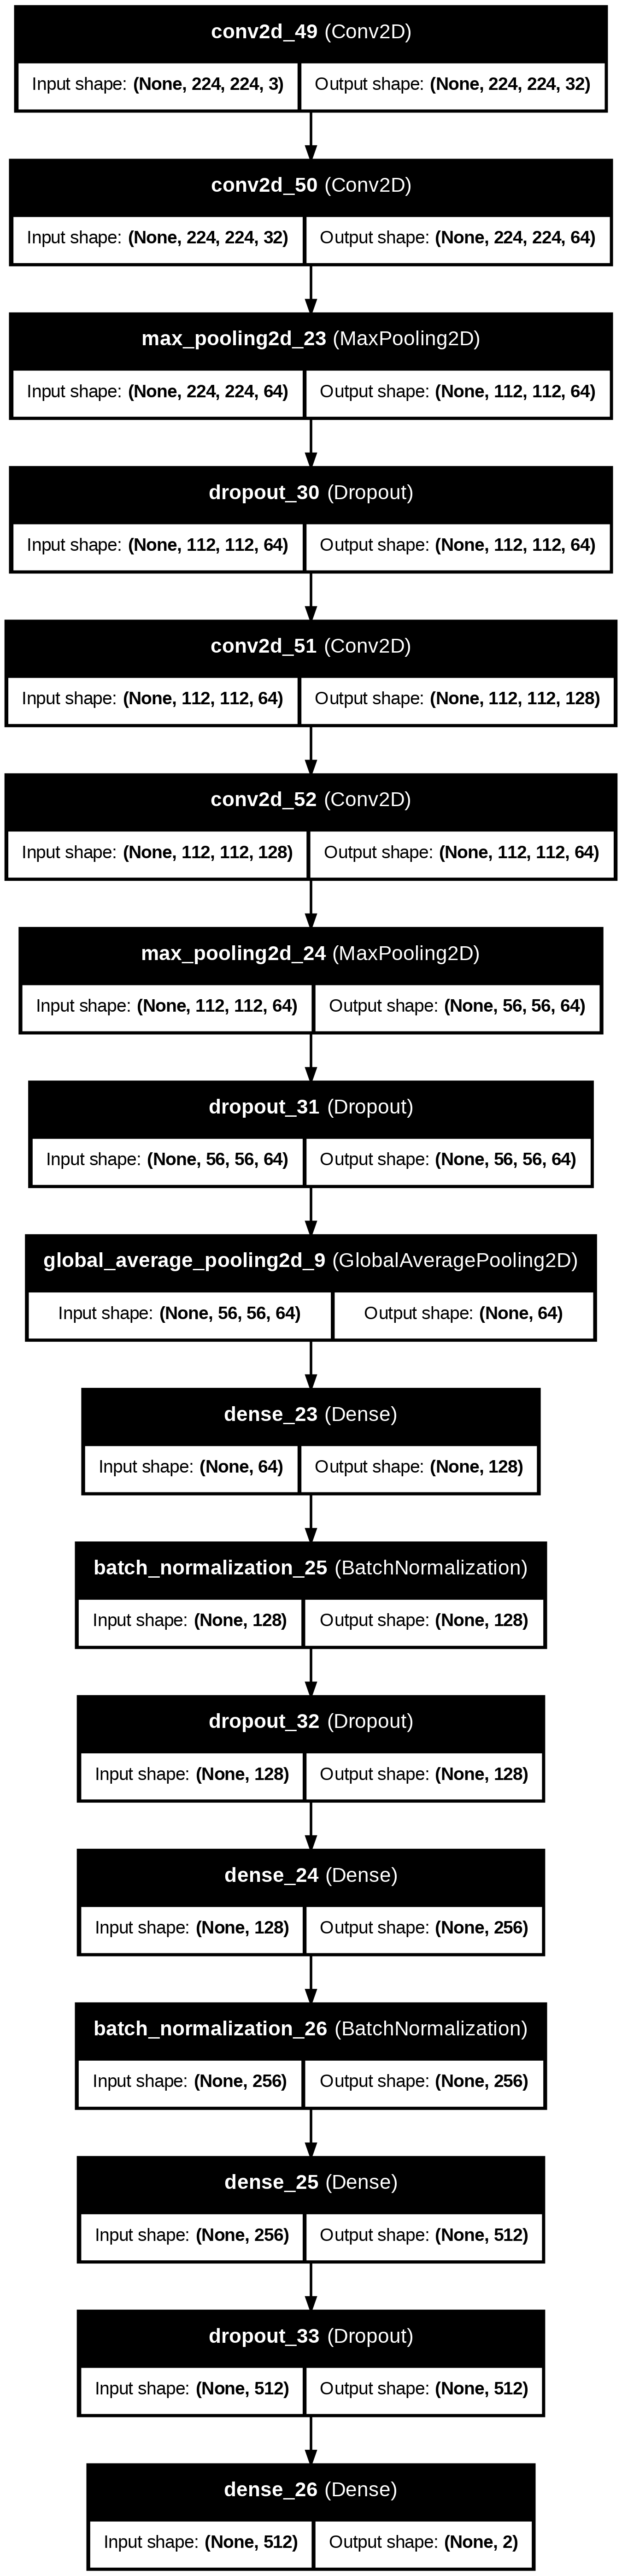

In [ ]:
tf.keras.utils.plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)


In [ ]:
optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

In [ ]:
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])


In [ ]:
epc = 5
bs = 8

In [ ]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_validate shape:", x_validate.shape)
print("y_validate shape:", y_validate.shape)


x_train shape: (57, 224, 224, 3)
y_train shape: (57, 2)
x_validate shape: (7, 224, 224, 3)
y_validate shape: (7, 2)


In [ ]:
print("x_train type:", type(x_train))
print("y_train type:", type(y_train))
print("x_train dtype:", x_train.dtype)
print("y_train dtype:", y_train.dtype)


x_train type: <class 'numpy.ndarray'>
y_train type: <class 'numpy.ndarray'>
x_train dtype: float64
y_train dtype: float64


In [ ]:
print("Model output shape after Flatten:", model.output_shape)


Model output shape after Flatten: (None, 2)


In [ ]:
model.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_49 (Conv2D)                   │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_50 (Conv2D)                   │ (None, 224, 224, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_51 (Conv2D)                   │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_52 (Conv2D)                   │ (None, 112, 112, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_9           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 342,530 (1.31 MB)

 Trainable params: 341,762 (1.30 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Modeli oluştur
model = model1(input_shape=(224, 224, 3), num_classes=2)

# Modeli derle (compile et)
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Modeli eğit
history = model.fit(x_train, y_train,
                    batch_size=bs,
                    epochs=epc,
                    validation_data=(x_validate, y_validate),
                    verbose=1,
                    callbacks=[learning_rate_reduction])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 203s 23s/step - accuracy: 0.7508 - loss: 2.2471 - val_accuracy: 0.4286 - val_loss: 339.7434 - learning_rate: 0.0010
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 178s 20s/step - accuracy: 0.7024 - loss: 8.4096 - val_accuracy: 0.4286 - val_loss: 3261.6980 - learning_rate: 0.0010
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 188s 18s/step - accuracy: 0.6865 - loss: 3.7247 - val_accuracy: 0.5714 - val_loss: 617.5963 - learning_rate: 0.0010
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 203s 18s/step - accuracy: 0.5933 - loss: 3.6464 - val_accuracy: 0.5714 - val_loss: 1576.7023 - learning_rate: 0.0010
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 204s 18s/step - accuracy: 0.6252 - loss: 2.5834 - val_accuracy: 0.2857 - val_loss: 357.6320 - learning_rate: 0.0010


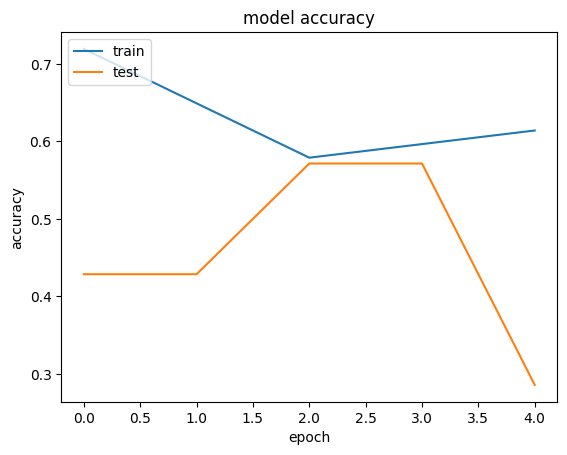

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

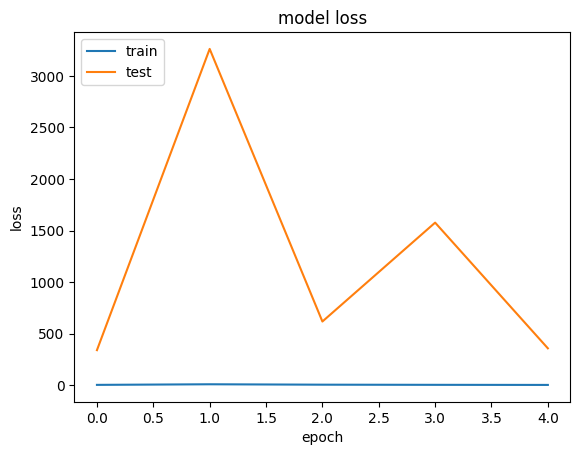

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [10]:
import itertools
import matplotlib.pyplot as plt # Add this import statement

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


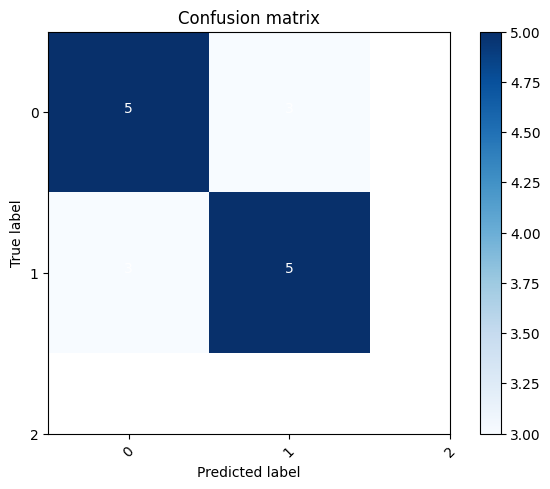

In [ ]:
Y_pred = model.predict(x_test)
Y_pred_classes = np.argmax(Y_pred,axis = 1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(y_test,axis = 1)  #test süreci için Y_true = np.argmax(y_test,axis = 1)
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(3))

In [ ]:
from sklearn.metrics import classification_report
report = classification_report(Y_true, Y_pred_classes)
print(report)

              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.62      0.62      0.62         8

    accuracy                           0.62        16
   macro avg       0.62      0.62      0.62        16
weighted avg       0.62      0.62      0.62        16



In [ ]:
model.save('/content/drive/MyDrive/horses_and_zebras/models/model1.keras')
#h5. yerine keras uzantısıyla yapınca uyarı vermedi

In [7]:
from tensorflow.keras.models import load_model

# Yeni formatta kaydedilen modeli yükleme
model = load_model('/content/drive/MyDrive/horses_and_zebras/models/model1.keras')

print("Model başarıyla yüklendi!")


Model başarıyla yüklendi!


In [ ]:
preds = model.predict(x_test)
y_pred = np.zeros_like(preds)
y_pred[np.arange(len(preds)), preds.argmax(1)] = 1
classes = ['cat','dog']
confusionMatrix = np.zeros((len(classes),len(classes)))

for i in range(len(y_test)):

  if np.array_equal(y_pred[i],y_test[i]):
    index = np.argmax(y_test[i])
    confusionMatrix[index,index] += 1

  else:

    index1 = np.argmax(y_test[i])
    index2 = np.argmax(y_pred[i])
    confusionMatrix[index1,index2] += 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.62      0.62      0.62         8

   micro avg       0.62      0.62      0.62        16
   macro avg       0.62      0.62      0.62        16
weighted avg       0.62      0.62      0.62        16
 samples avg       0.62      0.62      0.62        16

Accuracy Score : 
0.625
--------------------------------------------------
Confusion Matrix : 
[[5. 3.]
 [3. 5.]]
--------------------------------------------------


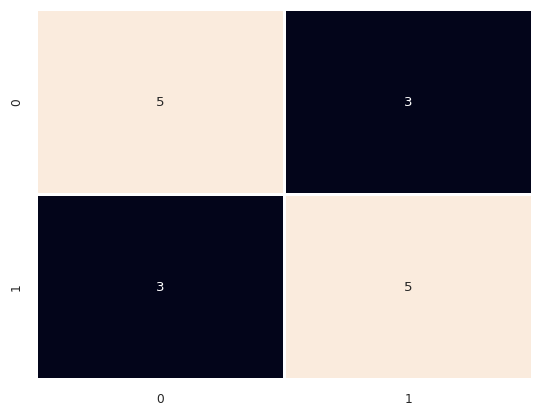

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))
print("Accuracy Score : ")
print(accuracy_score(y_test, y_pred))
cm = accuracy_score(y_test, y_pred)
sns.set(font_scale=0.8)
sns.heatmap(confusionMatrix,annot=True, linewidths=1.0, cbar=False)
print("--------------------------------------------------")
print("Confusion Matrix : ")
print(confusionMatrix)
print("--------------------------------------------------")

In [14]:
import numpy as np # Add this line at the beginning of the script

from tensorflow.keras.preprocessing.image import ImageDataGenerator # Add this line to import ImageDataGenerator
# load the dataset and labels
data = np.load(r"/content/drive/MyDrive/horses_and_zebras/imageArrays/224x224_images.npy")
labels = np.load(r"/content/drive/MyDrive/horses_and_zebras/imageArrays/224x224_labels.npy")

# encode the labels
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
labelEn = LabelEncoder()
labels = labelEn.fit_transform(labels)
labels = to_categorical(labels)

# split the dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size = .20, shuffle = True)

# split the training set into train and validation sets
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = .10, shuffle = True, random_state=42)

# split the training set into train and validation sets
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = .10, shuffle = True, random_state=42)

#ImageDataGenerator ile veri arttırım modelini kurgula ve datagen değikenine ata
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180) 10 degrees
        zoom_range = 0.1, # Randomly zoom image %10
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width) %10
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height) %10
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False  # randomly flip images
                        )
datagen.fit(x_train) #datagen'i x_train üzerinden çalıştır ve veri üret

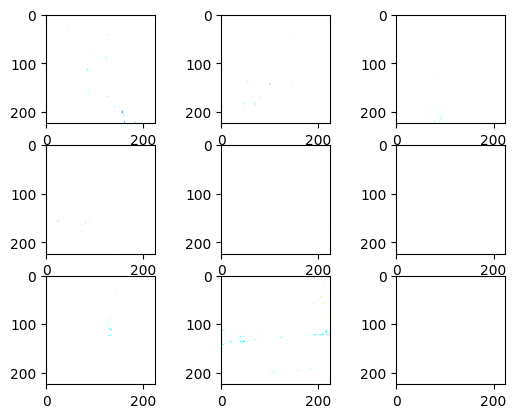

In [26]:
from matplotlib import pyplot
for X_batch, y_batch in datagen.flow(x_train, y_train, batch_size=9):
	# create a grid of 3x3 images
	for i in range(0, 9):
		pyplot.subplot(330 + 1 + i)
		pyplot.imshow(X_batch[i].reshape(224, 224,3))
	# show the plot
	pyplot.show()
	break

In [11]:
print(model)  # Model değişkenini kontrol et


<Sequential name=sequential_15, built=True>


In [50]:
history = model.fit(datagen.flow(np.array(x_train),np.array(y_train), batch_size=8), #bs ile 8 yer değiştirildi
                              epochs = 5, # Directly set the number of epochs, for example 5.
                              validation_data = datagen.flow(np.array(x_validate),
                             np.array(y_validate),batch_size=bs),verbose = 1,
                              steps_per_epoch=x_train.shape[0] // bs,
                              callbacks=[learning_rate_reduction])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 142s 18s/step - accuracy: 0.6970 - loss: 1.6573 - val_accuracy: 0.2857 - val_loss: 3589.2993 - learning_rate: 0.0010
Epoch 2/5
1/7 ━━━━━━━━━━━━━━━━━━━━ 1:51 19s/step - accuracy: 0.8750 - loss: 2.3130

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 855ms/step - accuracy: 0.8750 - loss: 2.3130 - val_accuracy: 0.2857 - val_loss: 1815.1726 - learning_rate: 0.0010
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 171s 17s/step - accuracy: 0.6857 - loss: 2.8054 - val_accuracy: 0.4286 - val_loss: 94.8294 - learning_rate: 0.0010
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 847ms/step - accuracy: 0.7500 - loss: 0.6840 - val_accuracy: 0.4286 - val_loss: 69.1865 - learning_rate: 0.0010
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 122s 17s/step - accuracy: 0.6507 - loss: 1.6282 - val_accuracy: 0.7143 - val_loss: 65.2512 - learning_rate: 0.0010


In [7]:
from keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Sequential # Add this line
from tensorflow.keras.layers import Flatten, Dropout, Dense

# Define image_width and image_height before using them
image_width = 224
image_height = 224

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(image_width ,image_height ,3)

)

In [8]:
NUM_CLASSES=2
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.layers[0].trainable = False #ilk katmana eklenen vgg16 modelini tekrar  train etme,
                                #imagenet'te train edilmiş ağırlıkları kullan

In [9]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │          50,178 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)

model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [44]:
# ipython-input-8-4b7f03e2680f
NUM_CLASSES=2
model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(NUM_CLASSES, activation='softmax')) # Make sure NUM_CLASSES is 2

model.layers[0].trainable = False

# Make sure y_train and y_validate are one-hot encoded:
from tensorflow.keras.utils import to_categorical

# Assuming your original labels are in a variable called 'labels'
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_validate = to_categorical(y_validate, num_classes=NUM_CLASSES)

In [49]:
# ipython-input-48-01991e39c29e
NUM_CLASSES=2
# Instead of creating a new model, modify the existing one
model = Sequential()  # Create a new Sequential model
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(NUM_CLASSES, activation='softmax')) # Make sure NUM_CLASSES is 2

model.layers[0].trainable = False

# Make sure y_train and y_validate are one-hot encoded:
from tensorflow.keras.utils import to_categorical

# Assuming your original labels are in a variable called 'labels'
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_validate = to_categorical(y_validate, num_classes=NUM_CLASSES)

# Compile the model after modifications and before fitting
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
